# K-Means – Full Pipeline

**Pipeline:**
```
Dữ liệu gốc (46D)
       ↓
[KMeans thường – không giảm chiều]
       ↓
[Giảm chiều] PCA (cont) + ghép discrete  |  UMAP (15D)
       ↓
[KMeans + PCA]  /  [KMeans + UMAP]
[KMeans + Gower | PCA]  /  [KMeans + Gower | UMAP]
[KMeans Constrained | PCA]  /  [KMeans Constrained | UMAP]
       ↓
[So sánh tổng hợp]
```

## 1. Import thư viện và cấu hình chung

In [1]:
# ============================================================
# THƯ VIỆN
# ============================================================

import numpy as np
import pandas as pd
import math
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.decomposition import PCA
import umap

from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    fowlkes_mallows_score,
)

from IPython.display import display, Markdown

COLORS = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6',
          '#1ABC9C', '#E67E22', '#34495E', '#E91E63', '#00BCD4']

RANDOM_STATE = 42
TARGET_COL   = 'charges'
DATA_PATH    = 'data/support2_final.csv'
K_CLUSTERS   = 3   # ← đổi nếu cần

## 2. Đọc dữ liệu và tách input/output

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()
feature_names = X.columns.tolist()
print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')

Shape: (8933, 47)
Missing values: 0
Features: 46 | Samples: 8933


## 3. Tách biến liên tục và biến rời rạc/binary

In [3]:
def infer_discrete_continuous_cols(X_df, max_unique_for_discrete=5):
    discrete_cols   = []
    continuous_cols = []
    for col in X_df.columns:
        values       = X_df[col].dropna().unique()
        unique_count = len(values)
        is_binary    = set(np.round(values, 8)).issubset({0, 1})
        if is_binary or unique_count <= max_unique_for_discrete:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)
    return continuous_cols, discrete_cols

continuous_cols, discrete_cols = infer_discrete_continuous_cols(X)
X_cont = X[continuous_cols].copy()
X_disc = X[discrete_cols].copy()

assert X_cont.shape[1] + X_disc.shape[1] == X.shape[1]
print(f'Biến liên tục : {X_cont.shape[1]} cột')
print(f'Biến rời rạc  : {X_disc.shape[1]} cột')

Biến liên tục : 25 cột
Biến rời rạc  : 21 cột


## 4. Giảm chiều – PCA và UMAP

In [4]:
# ----------------------------------------------------------
# PCA: chỉ áp dụng cho biến liên tục, ghép lại biến rời rạc
# ----------------------------------------------------------
pca_reducer = PCA(n_components=0.70, random_state=RANDOM_STATE)
X_cont_pca  = pca_reducer.fit_transform(X_cont)
X_pca_reduced = np.hstack([X_cont_pca, X_disc.values])
pca_col_names  = ([f'PC{i+1}' for i in range(X_cont_pca.shape[1])]
                  + list(X_disc.columns))
X_pca_reduced  = pd.DataFrame(X_pca_reduced,
                               columns=pca_col_names,
                               index=X.index)

# Tên cột discrete trong không gian PCA-reduced (dùng cho Gower)
discrete_cols_pca = list(X_disc.columns)

print(f'PCA: {X_cont.shape[1]}D → {X_cont_pca.shape[1]}D  '
      f'+ {X_disc.shape[1]}D rời rạc '
      f'= {X_pca_reduced.shape[1]}D '
      f'| variance: {pca_reducer.explained_variance_ratio_.sum():.2%}')

# ----------------------------------------------------------
# UMAP: áp dụng toàn bộ 46 chiều
# ----------------------------------------------------------
umap_reducer  = umap.UMAP(n_components=15, random_state=RANDOM_STATE)
X_umap_arr    = umap_reducer.fit_transform(X)
umap_col_names = [f'UMAP{i+1}' for i in range(X_umap_arr.shape[1])]
X_umap_reduced = pd.DataFrame(X_umap_arr,
                               columns=umap_col_names,
                               index=X.index)

# Không có cột rời rạc trong UMAP (tất cả đã nhúng về liên tục)
discrete_cols_umap = []

print(f'UMAP: {X.shape[1]}D → {X_umap_reduced.shape[1]}D')

PCA: 25D → 13D  + 21D rời rạc = 34D | variance: 71.79%
UMAP: 46D → 15D


## 5. Hàm chung – Đánh giá và Visualization

In [5]:
# ============================================================
# EVALUATE INTERNAL – Euclidean (KMeans thường + Constrained)
# ============================================================
def evaluate_internal(X, labels, model_name='KMeans'):
    """
    Đánh giá chất lượng cụm theo khoảng cách Euclidean.
    Dùng cho KMeans, KMeans Constrained.
    """
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    print(f"\n{'='*55}")
    print(f"  Internal Metrics (Euclidean) — {model_name}")
    print(f"{'='*55}")
    print(f"  Silhouette Score     : {sil:+.4f}  (↑ tốt hơn, max=1)")
    print(f"  Davies-Bouldin Index : {db:.4f}   (↓ tốt hơn, min=0)")
    print(f"  Calinski-Harabasz    : {ch:.1f}  (↑ tốt hơn)")
    print(f"{'='*55}\n")

    return {'model': model_name,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch}


# ============================================================
# EVALUATE INTERNAL – Gower (K-Medoids + Gower)
# ============================================================
def evaluate_internal_gower(D_gower, labels, model_name='K-Medoids + Gower'):
    """
    Đánh giá chất lượng cụm dựa trên Gower distance matrix.

    Tại sao cần hàm riêng?
    - Silhouette: sklearn hỗ trợ metric='precomputed' → truyền D_gower trực tiếp.
    - Davies-Bouldin & Calinski-Harabasz: sklearn KHÔNG hỗ trợ precomputed,
      nên ta tự tính từ D_gower:
        * DB  ~ tỉ lệ (độ rải nội cụm) / (khoảng cách giữa cụm)
        * CH  ~ tỉ lệ (phân tán liên cụm) / (phân tán nội cụm)
      Cả hai đều tính hoàn toàn từ D_gower nên đúng với không gian Gower.

    D_gower  : ma trận khoảng cách Gower, shape (n, n)
    labels   : nhãn cụm
    """
    D = np.asarray(D_gower, dtype=float)
    n = D.shape[0]
    unique_clusters = np.unique(labels)
    k = len(unique_clusters)

    # ---------------------------------------------------
    # 1. Silhouette – dùng metric precomputed
    # ---------------------------------------------------
    sil = silhouette_score(D, labels, metric='precomputed')

    # ---------------------------------------------------
    # 2. Intra-cluster scatter: s_i = mean pairwise dist trong cụm i
    #    (tương đương "radius" hay "diameter" của cụm)
    # ---------------------------------------------------
    cluster_sizes = np.array([np.sum(labels == c) for c in unique_clusters])

    intra_scatter = np.zeros(k)   # s_i
    for idx, c in enumerate(unique_clusters):
        mask = labels == c
        sub  = D[np.ix_(mask, mask)]
        ni   = sub.shape[0]
        if ni > 1:
            # mean pairwise (không kể đường chéo = 0)
            intra_scatter[idx] = sub.sum() / (ni * (ni - 1))
        else:
            intra_scatter[idx] = 0.0

    # ---------------------------------------------------
    # 3. Inter-cluster distance: d_ij = mean dist giữa cụm i và cụm j
    # ---------------------------------------------------
    inter_dist = np.zeros((k, k))
    for i, ci in enumerate(unique_clusters):
        for j, cj in enumerate(unique_clusters):
            if i == j:
                continue
            mask_i = labels == ci
            mask_j = labels == cj
            inter_dist[i, j] = D[np.ix_(mask_i, mask_j)].mean()

    # ---------------------------------------------------
    # 4. Davies-Bouldin Index (Gower)
    #    DB = (1/k) * sum_i [ max_{j≠i} (s_i + s_j) / d_ij ]
    # ---------------------------------------------------
    db_scores = []
    for i in range(k):
        ratios = []
        for j in range(k):
            if i == j:
                continue
            dij = inter_dist[i, j]
            if dij > 0:
                ratios.append((intra_scatter[i] + intra_scatter[j]) / dij)
            else:
                ratios.append(np.inf)
        db_scores.append(max(ratios) if ratios else 0.0)

    db = float(np.mean(db_scores))

    # ---------------------------------------------------
    # 5. Calinski-Harabasz Index (Gower)
    #    CH = [B / (k-1)] / [W / (n-k)]
    #    B  = sum_i n_i * d(centroid_i, global_centroid)^2
    #       → thay bằng mean dist từ cụm i đến tất cả các cụm khác
    #         (vì không có centroid thật trong không gian Gower)
    #    W  = sum_i sum_{x in C_i} d(x, medoid_i)^2
    # ---------------------------------------------------
    if k < 2:
        ch = 0.0
    else:
        # Medoid của mỗi cụm: điểm có tổng dist đến các điểm trong cụm nhỏ nhất
        medoid_indices = []
        for c in unique_clusters:
            mask      = np.where(labels == c)[0]
            sub_D     = D[np.ix_(mask, mask)]
            local_idx = np.argmin(sub_D.sum(axis=1))
            medoid_indices.append(mask[local_idx])

        # W: tổng khoảng cách bình phương đến medoid nội cụm
        W = 0.0
        for idx, c in enumerate(unique_clusters):
            mask = np.where(labels == c)[0]
            med  = medoid_indices[idx]
            W   += np.sum(D[mask, med] ** 2)

        # B: tổng khoảng cách bình phương giữa các medoid, nhân với cluster size
        B = 0.0
        for i, ci in enumerate(unique_clusters):
            for j, cj in enumerate(unique_clusters):
                if i >= j:
                    continue
                d_med = D[medoid_indices[i], medoid_indices[j]] ** 2
                B    += cluster_sizes[i] * cluster_sizes[j] * d_med
        # Chia cho n để scale về dạng mean
        B = B / n

        # Tránh chia cho 0
        W = max(W, 1e-10)
        ch = (B / (k - 1)) / (W / (n - k))

    print(f"\n{'='*60}")
    print(f"  Internal Metrics (Gower) — {model_name}")
    print(f"{'='*60}")
    print(f"  Silhouette (Gower precomputed)  : {sil:+.4f}  (↑ tốt hơn)")
    print(f"  Davies-Bouldin (Gower)          : {db:.4f}   (↓ tốt hơn)")
    print(f"  Calinski-Harabasz (Gower)       : {ch:.1f}  (↑ tốt hơn)")
    print(f"  [Intra-scatter per cluster]: {[f'{v:.4f}' for v in intra_scatter]}")
    print(f"{'='*60}\n")

    return {
        'model': model_name,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'intra_scatter': intra_scatter.tolist(),
    }

In [6]:
# ============================================================
# EVALUATE EXTERNAL
# ============================================================
def evaluate_external(df, labels, target_col='charges',
                       n_bins=3, model_name='KMeans'):
    df = df.copy()
    df['_cluster'] = labels

    bin_labels = ['Thấp', 'Trung bình', 'Cao'][:n_bins]
    df['_target_bin'] = pd.qcut(df[target_col], q=n_bins, labels=bin_labels)

    ari = adjusted_rand_score(df['_target_bin'], labels)
    fmi = fowlkes_mallows_score(df['_target_bin'], labels)

    mean_charges = df.groupby('_cluster')[target_col].mean().sort_values()

    print(f"\n{'='*55}")
    print(f"  External Metrics — {model_name} vs '{target_col}'")
    print(f"{'='*55}")
    print(f"  ARI : {ari:+.4f}  (>0 = tốt hơn ngẫu nhiên)")
    print(f"  FMI : {fmi:.4f}   (0→1, cao hơn tốt hơn)")
    print(f"\n  Mean '{target_col}' theo cụm:")
    for cid, val in mean_charges.items():
        print(f"    Cluster {cid}: {val:.4f}")
    print(f"\n  Crosstab cụm × mức {target_col}:")
    print(pd.crosstab(df['_cluster'], df['_target_bin'], margins=True))
    print(f"{'='*55}\n")

    return {'model': model_name, 'ari': ari, 'fmi': fmi,
            'mean_target_per_cluster': mean_charges.to_dict()}

In [7]:
# ============================================================
# VISUALIZATION HELPERS
# ============================================================

def plot_clusters_pca(X, labels, km_model=None, title='KMeans', ax=None):
    k   = len(np.unique(labels))
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X2  = pca.fit_transform(X)
    var = pca.explained_variance_ratio_
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))
    for c in range(k):
        mask = labels == c
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   c=COLORS[c], alpha=0.45, s=12, label=f'Cluster {c}')
    if km_model is not None and hasattr(km_model, 'cluster_centers_'):
        centroids_2d = pca.transform(km_model.cluster_centers_)
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                   c='black', marker='X', s=200, zorder=5, label='Centroid')
    ax.set_title(f'{title} – PCA 2D\n(PC1={var[0]:.1%}, PC2={var[1]:.1%})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.2)
    if standalone:
        plt.tight_layout(); plt.show()


def plot_clusters_umap(X, labels, km_model=None, title='KMeans', ax=None):
    k       = len(np.unique(labels))
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    X2      = reducer.fit_transform(X)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))
    for c in range(k):
        mask = labels == c
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   c=COLORS[c], alpha=0.45, s=12, label=f'Cluster {c}')
    if km_model is not None and hasattr(km_model, 'cluster_centers_'):
        centroids_2d = reducer.transform(km_model.cluster_centers_)
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                   c='black', marker='X', s=200, zorder=5, label='Centroid')
    ax.set_title(f'{title} – UMAP 2D', fontweight='bold', fontsize=10)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.2)
    if standalone:
        plt.tight_layout(); plt.show()


def plot_cluster_distribution(labels, title='KMeans', ax=None):
    k     = len(np.unique(labels))
    sizes = [np.sum(labels == c) for c in range(k)]
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(sizes,
           labels=[f'Cluster {c}\n({s:,})' for c, s in enumerate(sizes)],
           colors=COLORS[:k],
           autopct='%1.1f%%',
           startangle=140,
           wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax.set_title(f'Phân phối kích thước cụm — {title}', fontweight='bold')
    if standalone:
        plt.tight_layout(); plt.show()


def plot_feature_heatmap(df, labels, feature_names,
                         top_n=20, title='KMeans', ax=None):
    k  = len(np.unique(labels))
    df = df.copy(); df['_cluster'] = labels
    feats         = [f for f in feature_names if f in df.columns]
    cluster_means = np.array([
        df[df['_cluster'] == c][feats].mean().values for c in range(k)
    ])
    feat_std  = cluster_means.std(axis=0)
    top_idx   = np.argsort(feat_std)[::-1][:top_n]
    top_feats = [feats[i] for i in top_idx]
    data      = cluster_means[:, top_idx]
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(14, top_n * 0.7), 3 + k))
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=-1.5, vmax=1.5)
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(k))
    ax.set_yticklabels([f'Cluster {c} (n={np.sum(labels==c):,})'
                        for c in range(k)], fontsize=10)
    ax.set_title(f'Heatmap — Top {top_n} đặc trưng — {title}', fontweight='bold')
    for i in range(k):
        for j in range(len(top_feats)):
            ax.text(j, i, f'{data[i,j]:.2f}',
                    ha='center', va='center', fontsize=6, color='black')
    if standalone:
        plt.colorbar(im, ax=ax, label='Giá trị')
        plt.tight_layout(); plt.show()
    else:
        plt.colorbar(im, ax=ax, label='Giá trị')

In [8]:
# ============================================================
# FULL CLUSTER REPORT  (dùng evaluate_internal Euclidean)
# ============================================================
def full_cluster_report(
    X, df, labels,
    km_model=None, feature_names=None, df_for_heatmap=None,
    target_col='charges', model_name='KMeans',
    use_umap=False, top_n_features=20
):
    if df_for_heatmap is None:
        df_for_heatmap = df.copy()
    if feature_names is None:
        feature_names = df_for_heatmap.columns.tolist()
    feature_names = list(feature_names)

    internal = evaluate_internal(X, labels, model_name)
    external = evaluate_external(df, labels, target_col, model_name=model_name)

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f'Cluster Report — {model_name}', fontsize=15, fontweight='bold')

    if use_umap:
        plot_clusters_umap(X, labels, km_model, title=model_name, ax=axes[0, 0])
    else:
        plot_clusters_pca(X, labels, km_model, title=model_name, ax=axes[0, 0])

    plot_cluster_distribution(labels, model_name, ax=axes[0, 1])

    df_tmp = df.copy(); df_tmp['_cluster'] = labels
    mean_charges = df_tmp.groupby('_cluster')[target_col].mean()
    x_pos = np.arange(len(mean_charges))
    axes[0, 2].bar(x_pos, mean_charges.values,
                   color=[COLORS[c] for c in mean_charges.index],
                   edgecolor='white', linewidth=1.5)
    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels([f'Cluster {c}' for c in mean_charges.index])
    for i, (c, val) in enumerate(zip(mean_charges.index, mean_charges.values)):
        axes[0, 2].text(i, val + mean_charges.max() * 0.01,
                        f'{val:.3f}', ha='center', va='bottom',
                        fontsize=9, fontweight='bold')
    axes[0, 2].set_title(f'Mean {target_col} theo cụm — {model_name}', fontweight='bold')
    axes[0, 2].set_ylabel(f'Mean {target_col}')
    axes[0, 2].grid(True, axis='y', alpha=0.3)

    clusters = sorted(np.unique(labels))
    axes[1, 0].boxplot(
        [df_tmp[df_tmp['_cluster'] == c][target_col].values for c in clusters],
        labels=[f'Cluster {c}' for c in clusters],
        patch_artist=True,
        boxprops=dict(facecolor='#f0f0f0'),
        medianprops=dict(color='red', linewidth=2)
    )
    for c in clusters:
        vals = df_tmp[df_tmp['_cluster'] == c][target_col].values
        axes[1, 0].scatter(
            np.full(len(vals), c + 1) + np.random.uniform(-0.15, 0.15, len(vals)),
            vals, alpha=0.15, s=6, color=COLORS[c])
    axes[1, 0].set_title(f'Phân phối {target_col} theo cụm — {model_name}', fontweight='bold')
    axes[1, 0].set_xlabel('Cluster'); axes[1, 0].set_ylabel(target_col)
    axes[1, 0].grid(True, axis='y', alpha=0.3)

    plot_feature_heatmap(df_for_heatmap, labels, feature_names,
                         top_n=top_n_features, title=model_name, ax=axes[1, 1])

    axes[1, 2].axis('off')
    metric_text = (
        f"Internal Metrics (Euclidean)\n"
        f"Silhouette          : {internal['silhouette']:.4f}\n"
        f"Davies-Bouldin      : {internal['davies_bouldin']:.4f}\n"
        f"Calinski-Harabasz   : {internal['calinski_harabasz']:.1f}\n\n"
        f"External Metrics vs {target_col}\n"
        f"ARI : {external['ari']:.4f}\n"
        f"FMI : {external['fmi']:.4f}"
    )
    axes[1, 2].text(0.05, 0.75, metric_text, fontsize=13, va='top',
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='#f7f7f7', edgecolor='#cccccc'))
    axes[1, 2].set_title('Tóm tắt chỉ số đánh giá', fontweight='bold')

    plt.tight_layout(); plt.show()

    return {**internal, **{f'ext_{k}': v for k, v in external.items()}}


# ============================================================
# FULL CLUSTER REPORT – GOWER VERSION
# ============================================================
def full_cluster_report_gower(
    X_embed, D_gower, df, labels,
    gower_model=None, feature_names=None, df_for_heatmap=None,
    target_col='charges', model_name='K-Medoids + Gower',
    top_n_features=20
):
    """
    Report đặc biệt cho K-Medoids + Gower:
    - Đánh giá internal dùng D_gower (Gower-aware)
    - Visualize scatter trên X_embed (MDS 2D từ Gower)
    - Boxplot / heatmap / mean charges như bình thường
    """
    if df_for_heatmap is None:
        df_for_heatmap = df.copy()
    if feature_names is None:
        feature_names = df_for_heatmap.columns.tolist()
    feature_names = list(feature_names)

    # -- Đánh giá metric Gower --
    internal = evaluate_internal_gower(D_gower, labels, model_name)
    external = evaluate_external(df, labels, target_col, model_name=model_name)

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f'Cluster Report — {model_name}', fontsize=15, fontweight='bold')

    # [0,0] Scatter dựa trên MDS embedding từ D_gower (2 chiều đầu)
    X2 = X_embed[:, :2] if X_embed.shape[1] >= 2 else X_embed
    k  = len(np.unique(labels))
    for c in range(k):
        mask = labels == c
        axes[0, 0].scatter(X2[mask, 0], X2[mask, 1],
                           c=COLORS[c], alpha=0.45, s=12, label=f'Cluster {c}')
    axes[0, 0].set_title(f'{model_name} – MDS (Gower) 2D', fontweight='bold', fontsize=10)
    axes[0, 0].set_xlabel('MDS-1'); axes[0, 0].set_ylabel('MDS-2')
    axes[0, 0].legend(fontsize=8, markerscale=1.5)
    axes[0, 0].grid(True, alpha=0.2)

    plot_cluster_distribution(labels, model_name, ax=axes[0, 1])

    df_tmp = df.copy(); df_tmp['_cluster'] = labels
    mean_charges = df_tmp.groupby('_cluster')[target_col].mean()
    x_pos = np.arange(len(mean_charges))
    axes[0, 2].bar(x_pos, mean_charges.values,
                   color=[COLORS[c] for c in mean_charges.index],
                   edgecolor='white', linewidth=1.5)
    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels([f'Cluster {c}' for c in mean_charges.index])
    for i, (c, val) in enumerate(zip(mean_charges.index, mean_charges.values)):
        axes[0, 2].text(i, val + mean_charges.max() * 0.01, f'{val:.3f}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0, 2].set_title(f'Mean {target_col} theo cụm — {model_name}', fontweight='bold')
    axes[0, 2].set_ylabel(f'Mean {target_col}')
    axes[0, 2].grid(True, axis='y', alpha=0.3)

    clusters = sorted(np.unique(labels))
    axes[1, 0].boxplot(
        [df_tmp[df_tmp['_cluster'] == c][target_col].values for c in clusters],
        labels=[f'Cluster {c}' for c in clusters],
        patch_artist=True,
        boxprops=dict(facecolor='#f0f0f0'),
        medianprops=dict(color='red', linewidth=2)
    )
    for c in clusters:
        vals = df_tmp[df_tmp['_cluster'] == c][target_col].values
        axes[1, 0].scatter(
            np.full(len(vals), c + 1) + np.random.uniform(-0.15, 0.15, len(vals)),
            vals, alpha=0.15, s=6, color=COLORS[c])
    axes[1, 0].set_title(f'Phân phối {target_col} theo cụm — {model_name}', fontweight='bold')
    axes[1, 0].set_xlabel('Cluster'); axes[1, 0].set_ylabel(target_col)
    axes[1, 0].grid(True, axis='y', alpha=0.3)

    plot_feature_heatmap(df_for_heatmap, labels, feature_names,
                         top_n=top_n_features, title=model_name, ax=axes[1, 1])

    axes[1, 2].axis('off')
    metric_text = (
        f"Internal Metrics (Gower-aware)\n"
        f"Silhouette (Gower)        : {internal['silhouette']:.4f}\n"
        f"Davies-Bouldin (Gower)    : {internal['davies_bouldin']:.4f}\n"
        f"Calinski-Harabasz (Gower) : {internal['calinski_harabasz']:.1f}\n\n"
        f"External Metrics vs {target_col}\n"
        f"ARI : {external['ari']:.4f}\n"
        f"FMI : {external['fmi']:.4f}"
    )
    axes[1, 2].text(0.05, 0.75, metric_text, fontsize=12, va='top',
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='#eef7ff', edgecolor='#99c2e8'))
    axes[1, 2].set_title('Tóm tắt chỉ số đánh giá (Gower)', fontweight='bold')

    plt.tight_layout(); plt.show()

    return {**internal, **{f'ext_{k}': v for k, v in external.items()}}

## 6. Hàm tính Gower + K-Medoids + MDS

In [9]:
def gower_distance_matrix(X, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = []
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    X = X.copy()
    n = X.shape[0]
    categorical_cols = [c for c in categorical_cols if c in X.columns]
    numeric_cols     = [c for c in X.columns if c not in categorical_cols]
    D = np.zeros((n, n), dtype=float)
    n_features = len(numeric_cols) + len(categorical_cols)
    if n_features == 0:
        raise ValueError('Không có feature nào để tính Gower distance.')
    for col in numeric_cols:
        values    = X[col].astype(float).values
        min_val   = np.nanmin(values)
        max_val   = np.nanmax(values)
        range_val = max_val - min_val
        if range_val == 0:
            diff = np.zeros((n, n))
        else:
            vs   = (values - min_val) / range_val
            diff = np.abs(vs[:, None] - vs[None, :])
        D += diff
    for col in categorical_cols:
        values = X[col].values
        diff   = (values[:, None] != values[None, :]).astype(float)
        D += diff
    D = D / n_features
    return D


def kmedoids_precomputed(D, k=3, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)
    n   = D.shape[0]
    if D.shape[0] != D.shape[1]:
        raise ValueError('D phải là ma trận vuông.')
    if k > n:
        raise ValueError('k không được lớn hơn số mẫu.')
    medoid_idx = rng.choice(n, size=k, replace=False)
    for _ in range(max_iter):
        old_medoid_idx = medoid_idx.copy()
        labels = np.argmin(D[:, medoid_idx], axis=1)
        for cluster_id in range(k):
            cluster_points = np.where(labels == cluster_id)[0]
            if len(cluster_points) == 0:
                medoid_idx[cluster_id] = rng.integers(0, n)
                continue
            sub_D              = D[np.ix_(cluster_points, cluster_points)]
            total_distances    = sub_D.sum(axis=1)
            best_point         = cluster_points[np.argmin(total_distances)]
            medoid_idx[cluster_id] = best_point
        if np.array_equal(old_medoid_idx, medoid_idx):
            break
    labels = np.argmin(D[:, medoid_idx], axis=1)
    return labels, medoid_idx


def classical_mds(D, n_components=5):
    D = np.asarray(D)
    n = D.shape[0]
    D_squared = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D_squared @ J
    eigvals, eigvecs = np.linalg.eigh(B)
    idx    = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]; eigvecs = eigvecs[:, idx]
    positive_idx = eigvals > 0
    eigvals = eigvals[positive_idx]; eigvecs = eigvecs[:, positive_idx]
    n_components = min(n_components, len(eigvals))
    X_embed = eigvecs[:, :n_components] * np.sqrt(eigvals[:n_components])
    return X_embed


class DummyMedoidModel:
    def __init__(self, labels=None, X_embed=None):
        self.labels_ = labels
        self.X_embed = X_embed

## 7. Runner functions cho từng phương pháp

In [10]:
# ============================================================
# RUNNER: KMeans thường (không giảm chiều)
# ============================================================
def run_kmeans_baseline(X_cluster, df, X_original,
                        k=3, target_col='charges', random_state=42):
    print(f"\n{'='*70}")
    print(f"KMeans Baseline | k={k} | không giảm chiều")
    print(f"{'='*70}")
    X_array = X_cluster.values if hasattr(X_cluster, 'values') else np.asarray(X_cluster)
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = km.fit_predict(X_array)
    metrics = full_cluster_report(
        X=X_array, df=df, labels=labels, km_model=km,
        feature_names=X_original.columns.tolist(),
        df_for_heatmap=X_original,
        target_col=target_col, model_name='KMeans Baseline',
        use_umap=False)
    metrics.update({'method': 'KMeans Baseline', 'dim_reduction': 'None', 'k': k})
    return labels, metrics, km


# ============================================================
# RUNNER: KMeans + giảm chiều (PCA hoặc UMAP)
# ============================================================
def run_kmeans_reduced(X_reduced, df, X_original,
                       k=3, dim_name='PCA',
                       target_col='charges', random_state=42):
    print(f"\n{'='*70}")
    print(f"KMeans + {dim_name} | k={k}")
    print(f"{'='*70}")
    X_array = X_reduced.values if hasattr(X_reduced, 'values') else np.asarray(X_reduced)
    km      = KMeans(n_clusters=k, n_init=20, random_state=random_state)
    labels  = km.fit_predict(X_array)
    metrics = full_cluster_report(
        X=X_array, df=df, labels=labels, km_model=km,
        feature_names=X_original.columns.tolist(),
        df_for_heatmap=X_original,
        target_col=target_col,
        model_name=f'KMeans + {dim_name}',
        use_umap=(dim_name.upper() == 'UMAP'))
    metrics.update({'method': 'KMeans', 'dim_reduction': dim_name, 'k': k})
    return labels, metrics, km


# ============================================================
# RUNNER: K-Medoids + Gower trên dữ liệu đã giảm chiều
# ============================================================
def run_kmedoids_gower(
    X_cluster, df, X_original,
    k=3, dim_name='PCA',
    categorical_cols=None,
    target_col='charges', random_state=42, top_n_features=20
):
    if categorical_cols is None:
        categorical_cols = []

    print(f"\n{'='*70}")
    print(f"K-Medoids + Gower | {dim_name} | k={k}")
    print(f"{'='*70}")
    print(f'Shape dữ liệu phân cụm: {X_cluster.shape}')

    print('Đang tính Gower distance matrix...')
    D_gower = gower_distance_matrix(X_cluster, categorical_cols=categorical_cols)

    labels, medoid_idx = kmedoids_precomputed(D_gower, k=k, random_state=random_state)

    print(f'Medoid indices : {medoid_idx}')
    print('Phân phối cụm:')
    print(pd.Series(labels).value_counts().sort_index())

    X_embed = classical_mds(D_gower, n_components=5)
    gower_model = DummyMedoidModel(labels=labels, X_embed=X_embed)

    # ---- Report dùng hàm Gower-aware ----
    metrics = full_cluster_report_gower(
        X_embed=X_embed,
        D_gower=D_gower,
        df=df,
        labels=labels,
        gower_model=gower_model,
        feature_names=X_original.columns.tolist(),
        df_for_heatmap=X_original,
        target_col=target_col,
        model_name=f'K-Medoids + Gower | {dim_name}',
        top_n_features=top_n_features
    )

    metrics.update({
        'method': 'K-Medoids + Gower',
        'dim_reduction': dim_name,
        'k': k
    })

    return labels, metrics, gower_model, D_gower, X_embed, medoid_idx


# ============================================================
# RUNNER: KMeans Constrained trên dữ liệu đã giảm chiều
# ============================================================
def run_kmeans_constrained(
    X_cluster, df, X_original,
    k=3, dim_name='PCA', tolerance=0.05,
    target_col='charges', random_state=42, top_n_features=20
):
    print(f"\n{'='*70}")
    print(f"KMeans Constrained | {dim_name} | k={k} | tolerance={tolerance}")
    print(f"{'='*70}")

    X_array  = X_cluster.values if hasattr(X_cluster, 'values') else np.asarray(X_cluster)
    n_samples = X_array.shape[0]
    base     = n_samples // k
    size_min = int(base * (1 - tolerance))
    size_max = math.ceil(base * (1 + tolerance))

    print(f'Số mẫu: {n_samples} | base/cụm: {base} | [{size_min}, {size_max}]')

    kcc = KMeansConstrained(
        n_clusters=k, size_min=size_min, size_max=size_max,
        random_state=random_state)
    labels = kcc.fit_predict(X_array)

    print('Phân phối cụm:')
    print(pd.Series(labels).value_counts().sort_index())

    metrics = full_cluster_report(
        X=X_array, df=df, labels=labels, km_model=kcc,
        feature_names=X_original.columns.tolist(),
        df_for_heatmap=X_original,
        target_col=target_col,
        model_name=f'KMeans Constrained | {dim_name}',
        use_umap=(dim_name.upper() == 'UMAP'),
        top_n_features=top_n_features
    )
    metrics.update({
        'method': 'KMeans Constrained', 'dim_reduction': dim_name, 'k': k,
        'size_min': size_min, 'size_max': size_max, 'tolerance': tolerance
    })
    return labels, metrics, kcc

## 8. Chạy toàn bộ pipeline

### 8.1 KMeans Baseline (không giảm chiều)


KMeans Baseline | k=3 | không giảm chiều

  Internal Metrics (Euclidean) — KMeans Baseline
  Silhouette Score     : +0.0873  (↑ tốt hơn, max=1)
  Davies-Bouldin Index : 2.9884   (↓ tốt hơn, min=0)
  Calinski-Harabasz    : 622.2  (↑ tốt hơn)


  External Metrics — KMeans Baseline vs 'charges'
  ARI : +0.1895  (>0 = tốt hơn ngẫu nhiên)
  FMI : 0.4816   (0→1, cao hơn tốt hơn)

  Mean 'charges' theo cụm:
    Cluster 1: 9.4633
    Cluster 2: 10.2039
    Cluster 0: 11.0956

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0             226         965  2075  3266
1            2351        1464   477  4292
2             401         548   426  1375
All          2978        2977  2978  8933



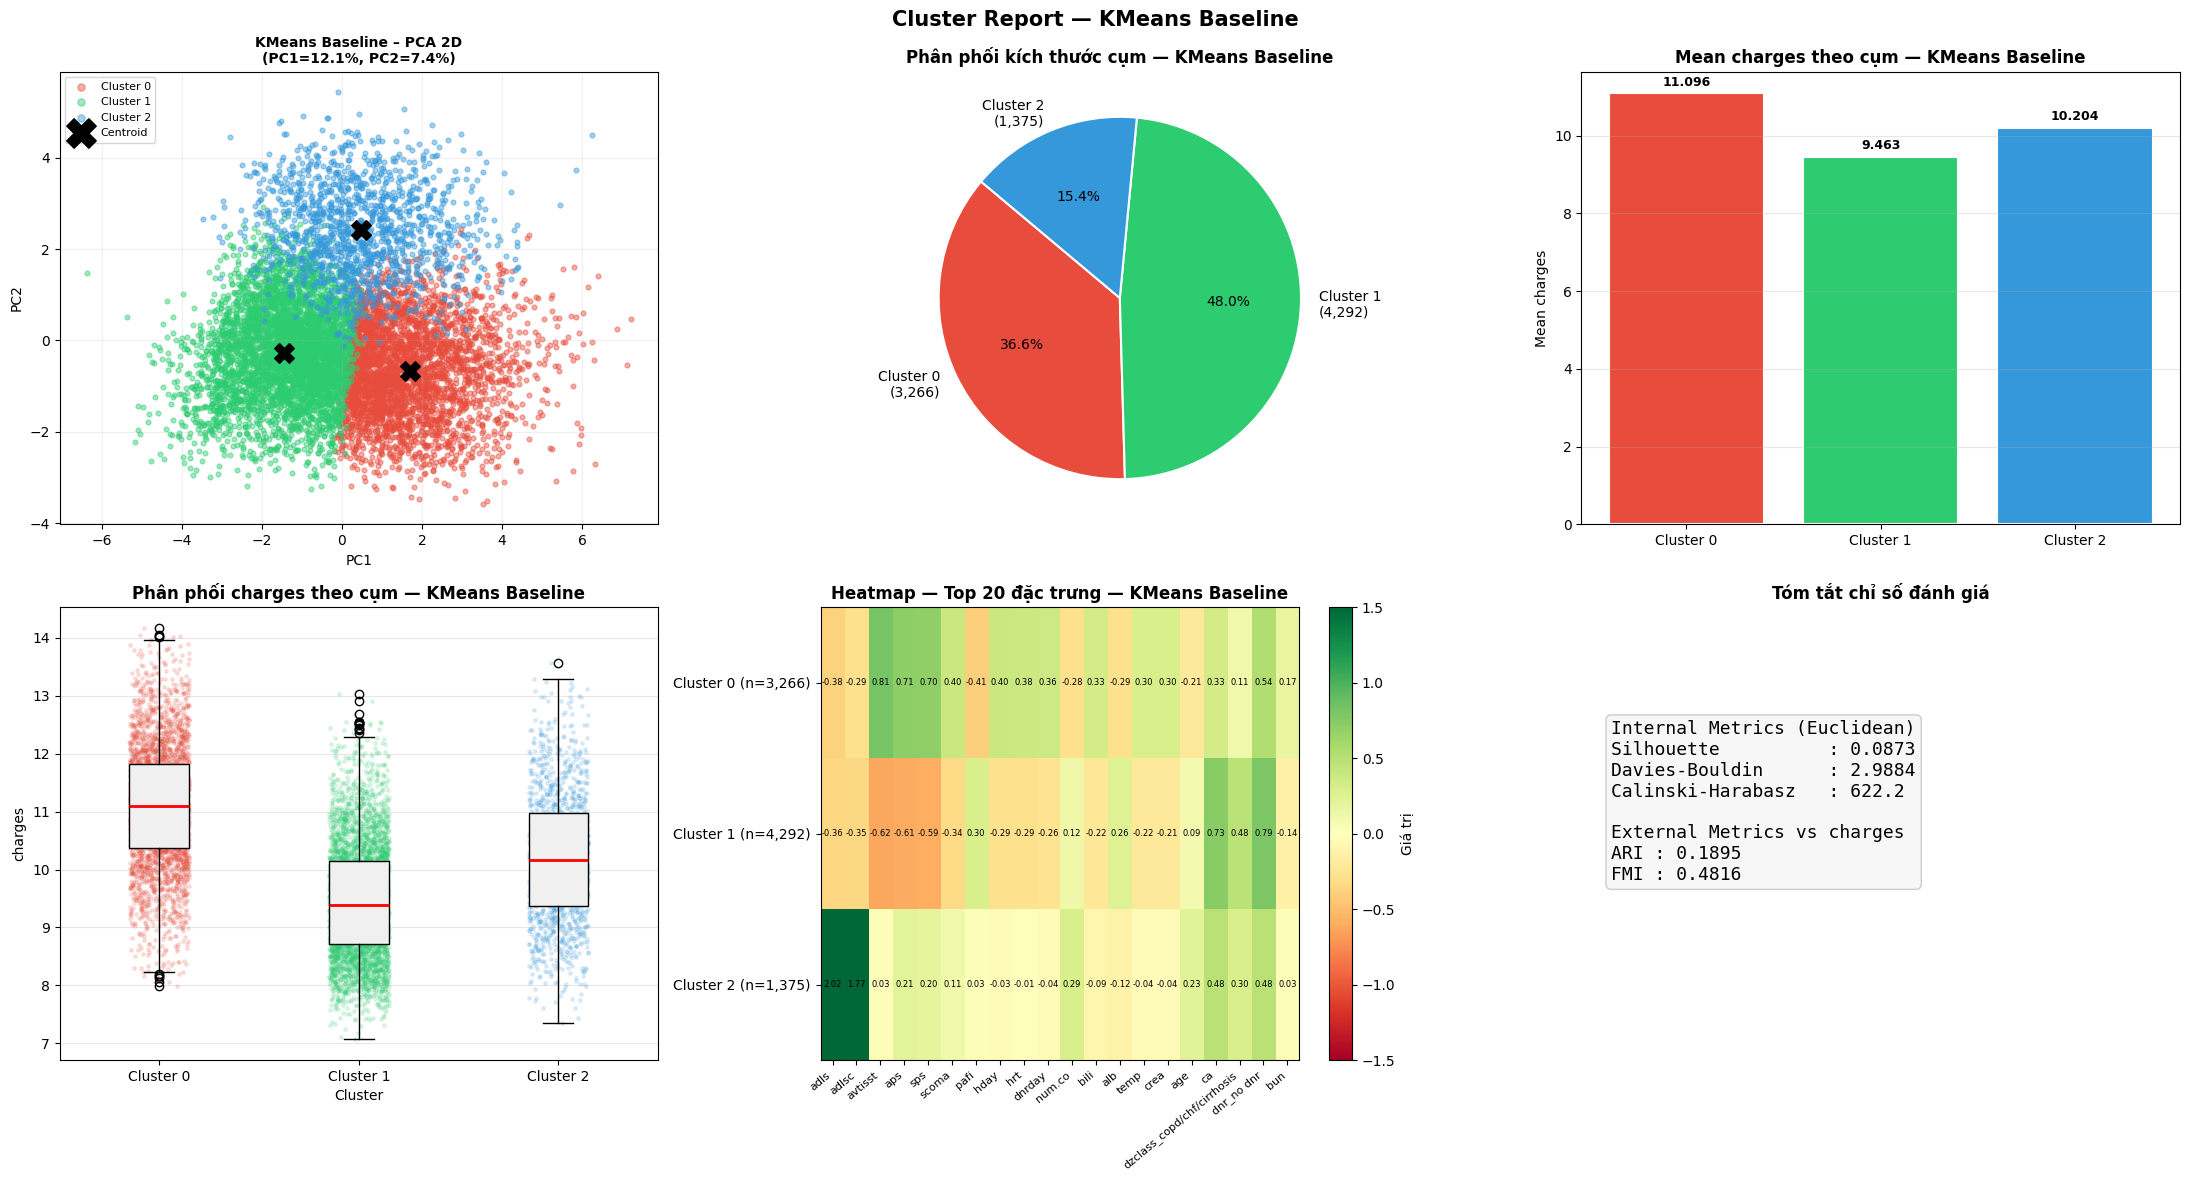

In [11]:
baseline_labels, baseline_metrics, baseline_model = run_kmeans_baseline(
    X_cluster=X,
    df=df,
    X_original=X,
    k=K_CLUSTERS,
    target_col=TARGET_COL
)

### 8.2 KMeans + PCA


KMeans + PCA | k=3

  Internal Metrics (Euclidean) — KMeans + PCA
  Silhouette Score     : +0.1125  (↑ tốt hơn, max=1)
  Davies-Bouldin Index : 2.5224   (↓ tốt hơn, min=0)
  Calinski-Harabasz    : 862.2  (↑ tốt hơn)


  External Metrics — KMeans + PCA vs 'charges'
  ARI : +0.1860  (>0 = tốt hơn ngẫu nhiên)
  FMI : 0.4786   (0→1, cao hơn tốt hơn)

  Mean 'charges' theo cụm:
    Cluster 2: 9.4729
    Cluster 0: 10.1928
    Cluster 1: 11.1043

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0             418         566   435  1419
1             220         940  2053  3213
2            2340        1471   490  4301
All          2978        2977  2978  8933



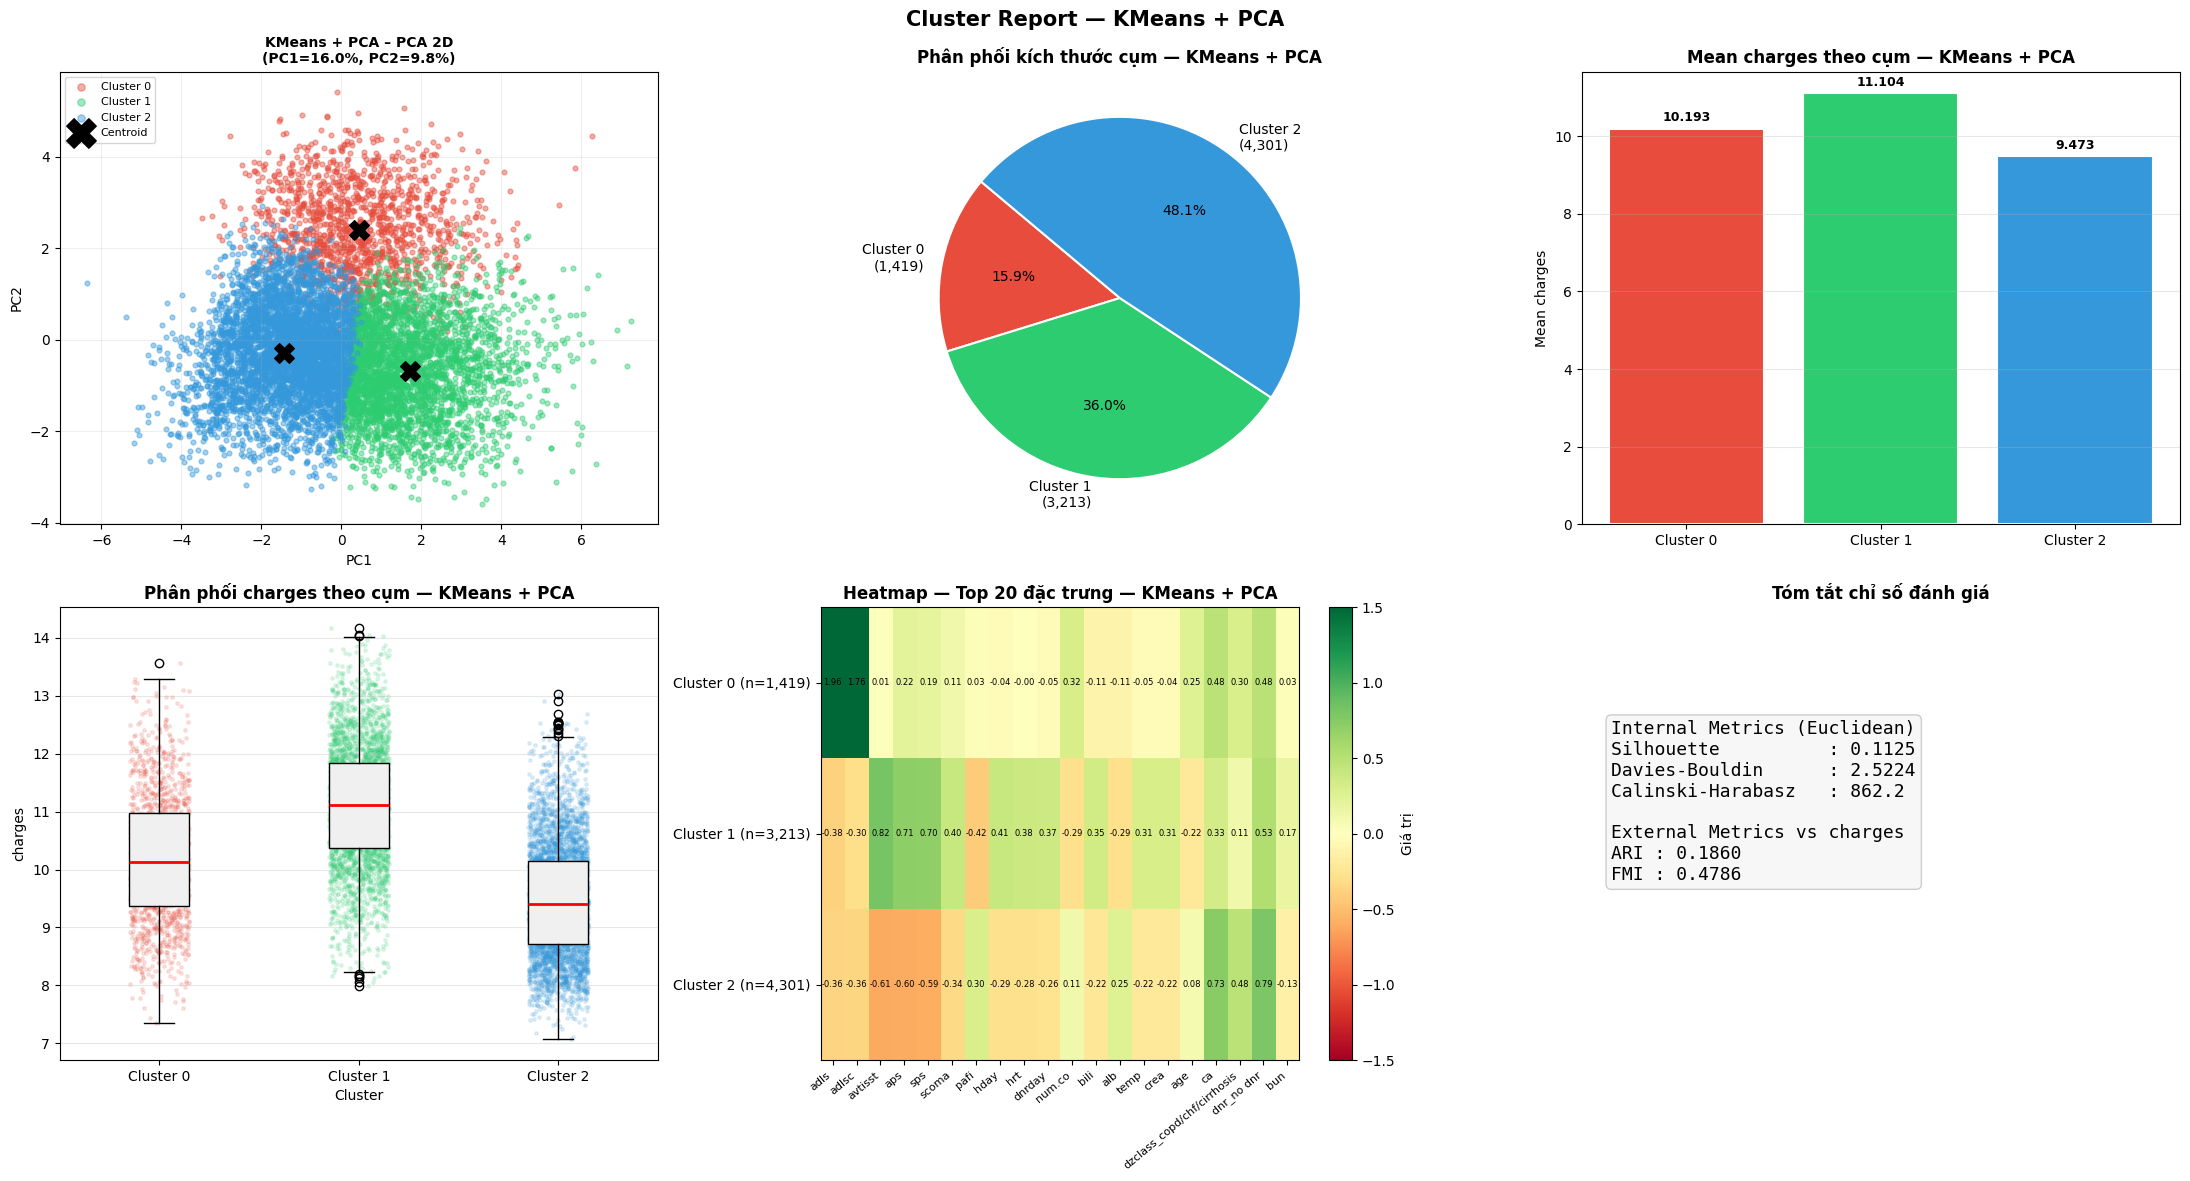

In [12]:
km_pca_labels, km_pca_metrics, km_pca_model = run_kmeans_reduced(
    X_reduced=X_pca_reduced,
    df=df,
    X_original=X,
    k=K_CLUSTERS,
    dim_name='PCA',
    target_col=TARGET_COL
)

### 8.3 KMeans + UMAP


KMeans + UMAP | k=3

  Internal Metrics (Euclidean) — KMeans + UMAP
  Silhouette Score     : +0.3765  (↑ tốt hơn, max=1)
  Davies-Bouldin Index : 1.0674   (↓ tốt hơn, min=0)
  Calinski-Harabasz    : 10301.8  (↑ tốt hơn)


  External Metrics — KMeans + UMAP vs 'charges'
  ARI : +0.1564  (>0 = tốt hơn ngẫu nhiên)
  FMI : 0.4580   (0→1, cao hơn tốt hơn)

  Mean 'charges' theo cụm:
    Cluster 1: 9.1899
    Cluster 2: 9.6761
    Cluster 0: 10.9479

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0             388        1301  2337  4026
1             931         403    48  1382
2            1659        1273   593  3525
All          2978        2977  2978  8933



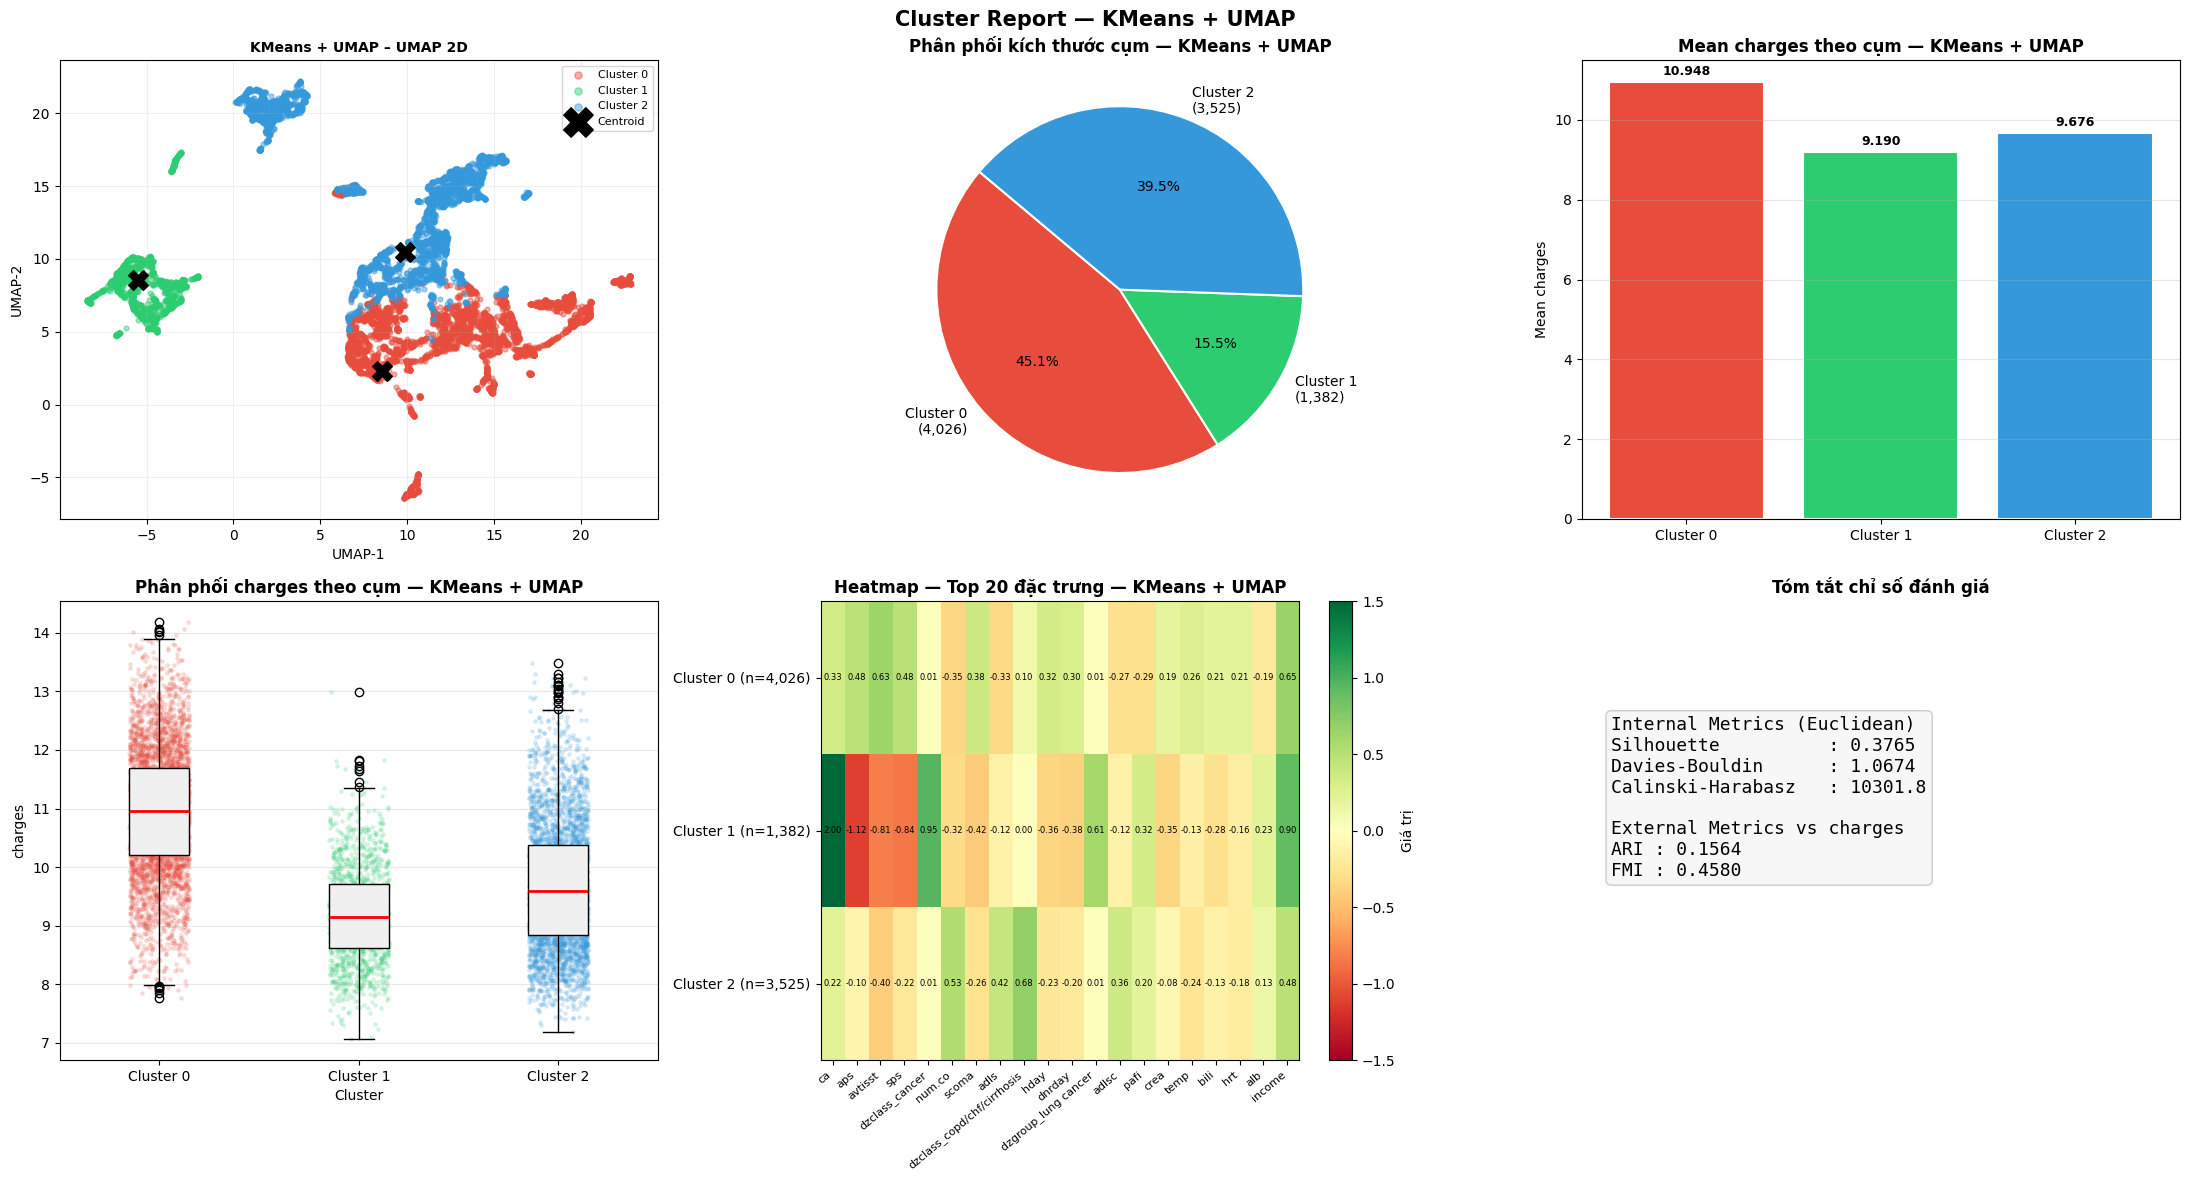

In [13]:
km_umap_labels, km_umap_metrics, km_umap_model = run_kmeans_reduced(
    X_reduced=X_umap_reduced,
    df=df,
    X_original=X,
    k=K_CLUSTERS,
    dim_name='UMAP',
    target_col=TARGET_COL
)

### 8.4 K-Medoids + Gower | PCA

> **Lưu ý về metric:** Gower không phải Euclidean → dùng `evaluate_internal_gower` riêng:
> - Silhouette: `metric='precomputed'` với D_gower
> - Davies-Bouldin & Calinski-Harabasz: tính thủ công từ D_gower (mean pairwise intra/inter-cluster)
> - Visualize: scatter dựa trên MDS embedding từ D_gower


K-Medoids + Gower | PCA | k=3
Shape dữ liệu phân cụm: (8933, 34)
Đang tính Gower distance matrix...
Medoid indices : [1449 4695 6153]
Phân phối cụm:
0    1133
1    2131
2    5669
Name: count, dtype: int64

  Internal Metrics (Gower) — K-Medoids + Gower | PCA
  Silhouette (Gower precomputed)  : +0.1178  (↑ tốt hơn)
  Davies-Bouldin (Gower)          : 1.7267   (↓ tốt hơn)
  Calinski-Harabasz (Gower)       : 568.6  (↑ tốt hơn)
  [Intra-scatter per cluster]: ['0.1830', '0.1455', '0.1729']


  External Metrics — K-Medoids + Gower | PCA vs 'charges'
  ARI : +0.0468  (>0 = tốt hơn ngẫu nhiên)
  FMI : 0.4270   (0→1, cao hơn tốt hơn)

  Mean 'charges' theo cụm:
    Cluster 1: 9.4112
    Cluster 0: 10.3838
    Cluster 2: 10.4189

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0             331         355   447  1133
1            1238         661   232  2131
2            1409        1961  2299  5669
All          2978        2977

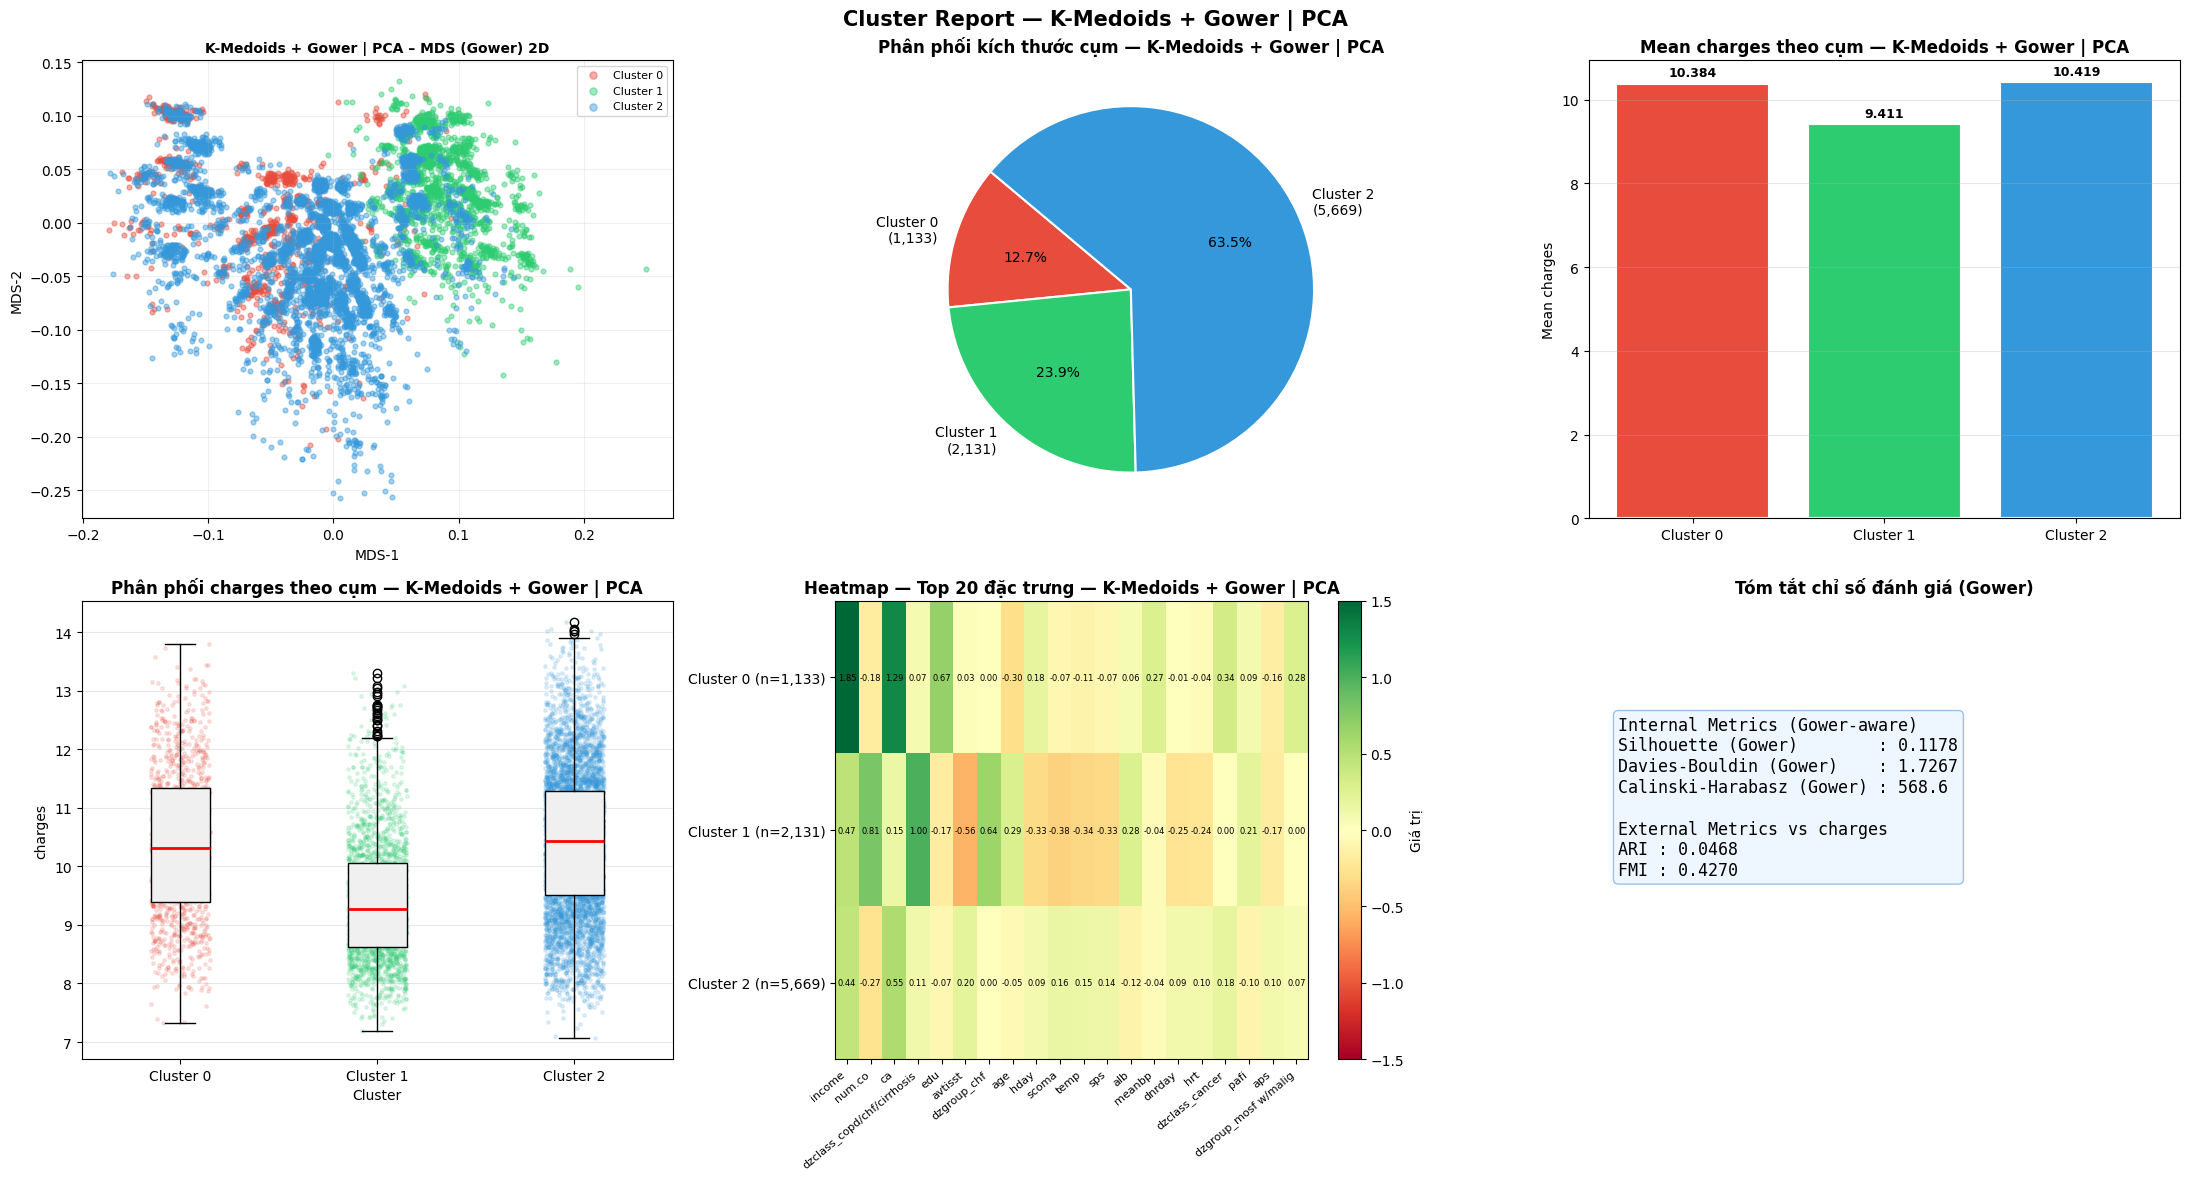

In [14]:
(
    gower_pca_labels,
    gower_pca_metrics,
    gower_pca_model,
    D_gower_pca,
    X_embed_pca,
    medoid_pca_idx
) = run_kmedoids_gower(
    X_cluster=X_pca_reduced,
    df=df,
    X_original=X,
    k=K_CLUSTERS,
    dim_name='PCA',
    categorical_cols=discrete_cols_pca,   # cột rời rạc trong không gian PCA-reduced
    target_col=TARGET_COL
)

### 8.5 K-Medoids + Gower | UMAP


K-Medoids + Gower | UMAP | k=3
Shape dữ liệu phân cụm: (8933, 15)
Đang tính Gower distance matrix...
Medoid indices : [4133 6854 4565]
Phân phối cụm:
0    1384
1    3275
2    4274
Name: count, dtype: int64

  Internal Metrics (Gower) — K-Medoids + Gower | UMAP
  Silhouette (Gower precomputed)  : +0.3926  (↑ tốt hơn)
  Davies-Bouldin (Gower)          : 1.0874   (↓ tốt hơn)
  Calinski-Harabasz (Gower)       : 9967.3  (↑ tốt hơn)
  [Intra-scatter per cluster]: ['0.0864', '0.1528', '0.1534']


  External Metrics — K-Medoids + Gower | UMAP vs 'charges'
  ARI : +0.1427  (>0 = tốt hơn ngẫu nhiên)
  FMI : 0.4511   (0→1, cao hơn tốt hơn)

  Mean 'charges' theo cụm:
    Cluster 0: 9.1910
    Cluster 1: 9.6788
    Cluster 2: 10.8719

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0             932         403    49  1384
1            1544        1172   559  3275
2             502        1402  2370  4274
All          2978        2

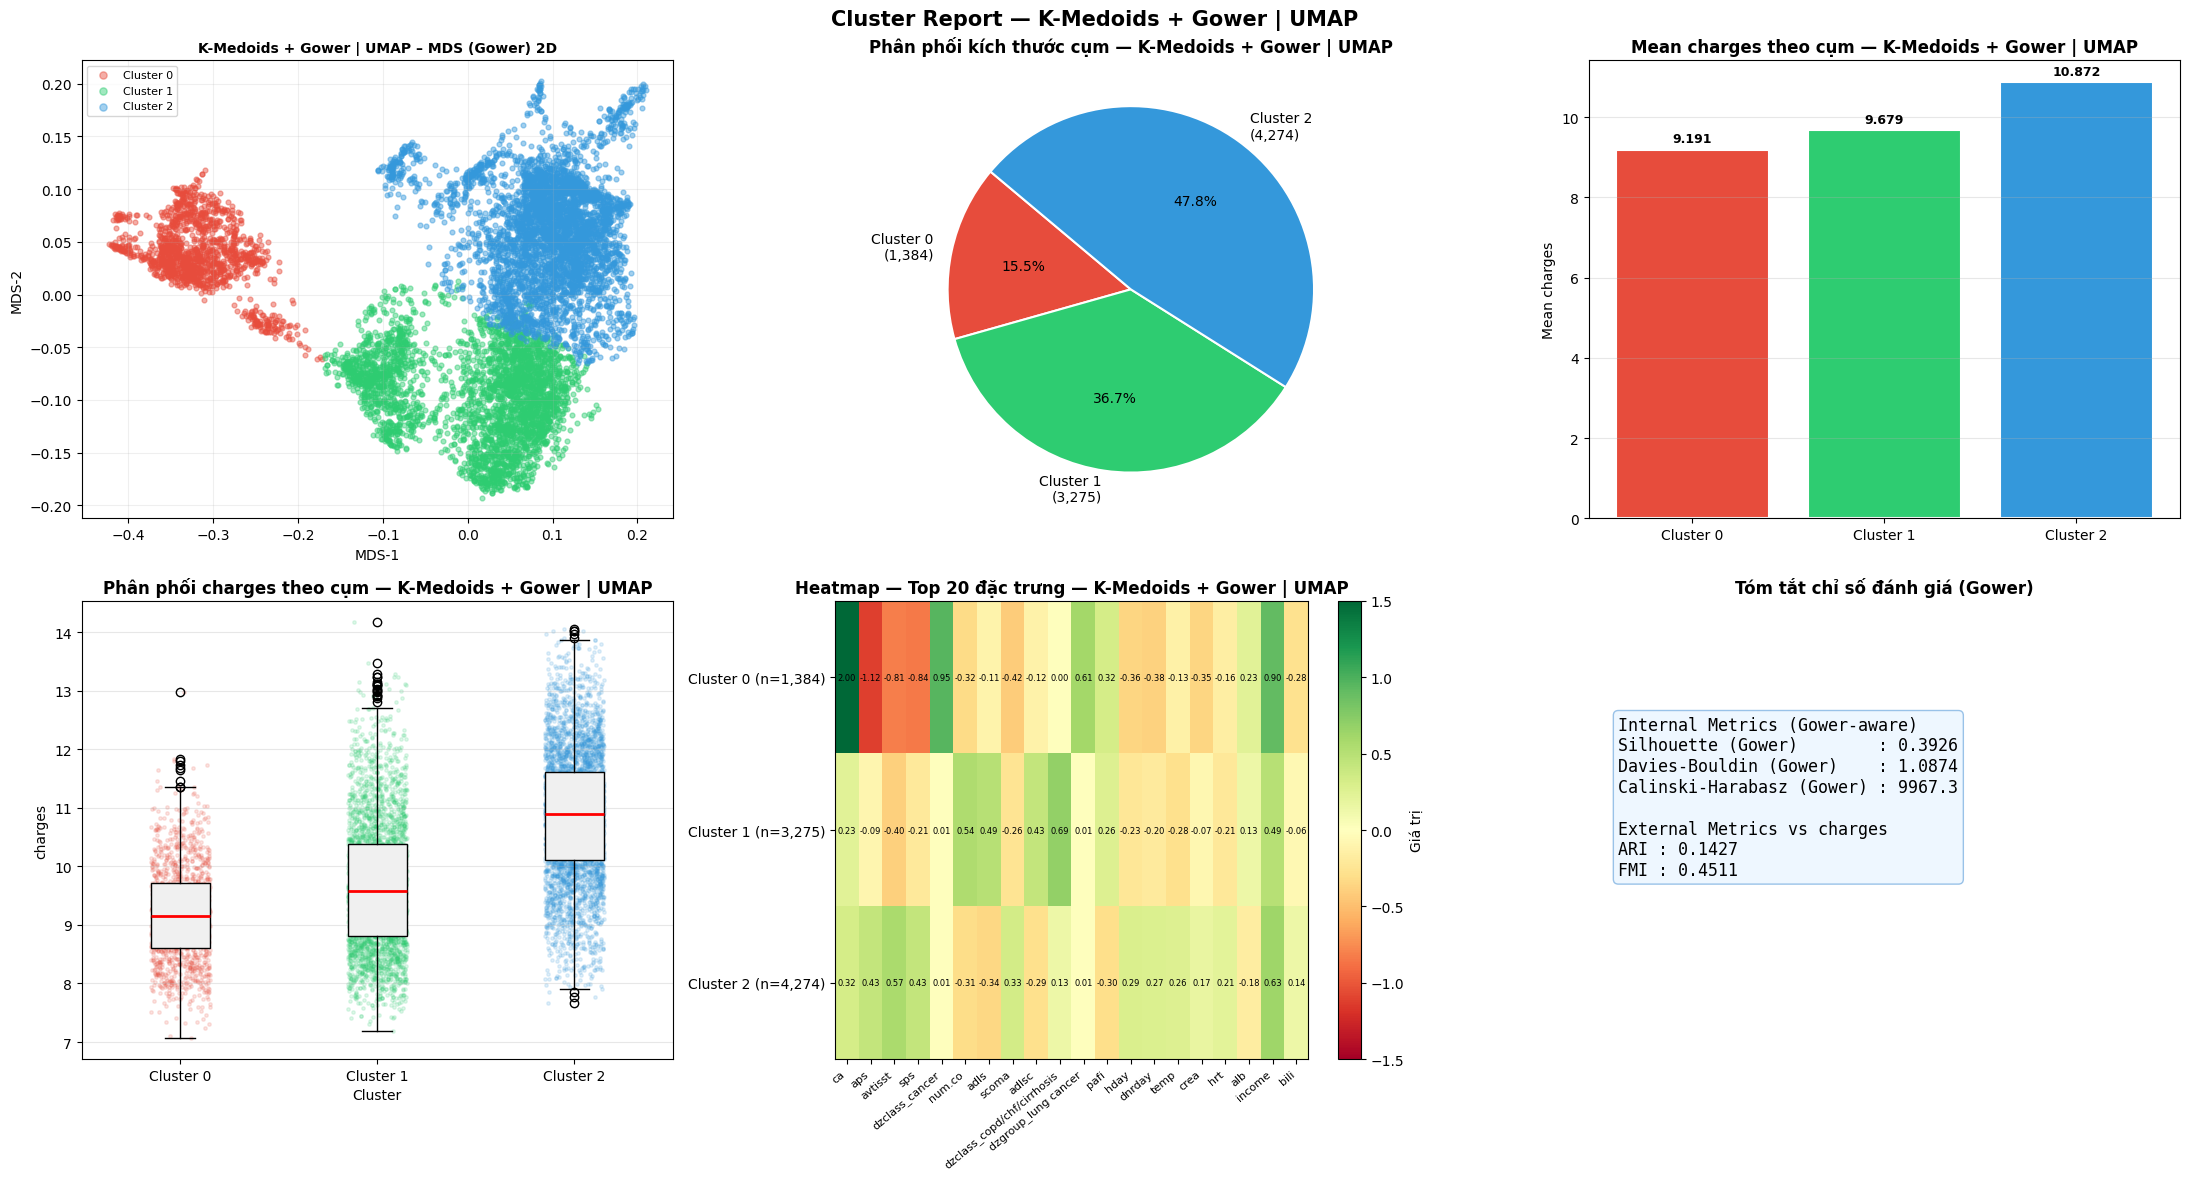

In [15]:
(
    gower_umap_labels,
    gower_umap_metrics,
    gower_umap_model,
    D_gower_umap,
    X_embed_umap,
    medoid_umap_idx
) = run_kmedoids_gower(
    X_cluster=X_umap_reduced,
    df=df,
    X_original=X,
    k=K_CLUSTERS,
    dim_name='UMAP',
    categorical_cols=discrete_cols_umap,  # [] vì UMAP đã nhúng hết về liên tục
    target_col=TARGET_COL
)

### 8.6 KMeans Constrained | PCA


KMeans Constrained | PCA | k=3 | tolerance=0.05
Số mẫu: 8933 | base/cụm: 2977 | [2828, 3126]
Phân phối cụm:
0    3126
1    2979
2    2828
Name: count, dtype: int64

  Internal Metrics (Euclidean) — KMeans Constrained | PCA
  Silhouette Score     : +0.0771  (↑ tốt hơn, max=1)
  Davies-Bouldin Index : 2.8661   (↓ tốt hơn, min=0)
  Calinski-Harabasz    : 807.3  (↑ tốt hơn)


  External Metrics — KMeans Constrained | PCA vs 'charges'
  ARI : +0.1623  (>0 = tốt hơn ngẫu nhiên)
  FMI : 0.4417   (0→1, cao hơn tốt hơn)

  Mean 'charges' theo cụm:
    Cluster 0: 9.4383
    Cluster 2: 9.9228
    Cluster 1: 11.1847

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0            1765        1022   339  3126
1             158         826  1995  2979
2            1055        1129   644  2828
All          2978        2977  2978  8933



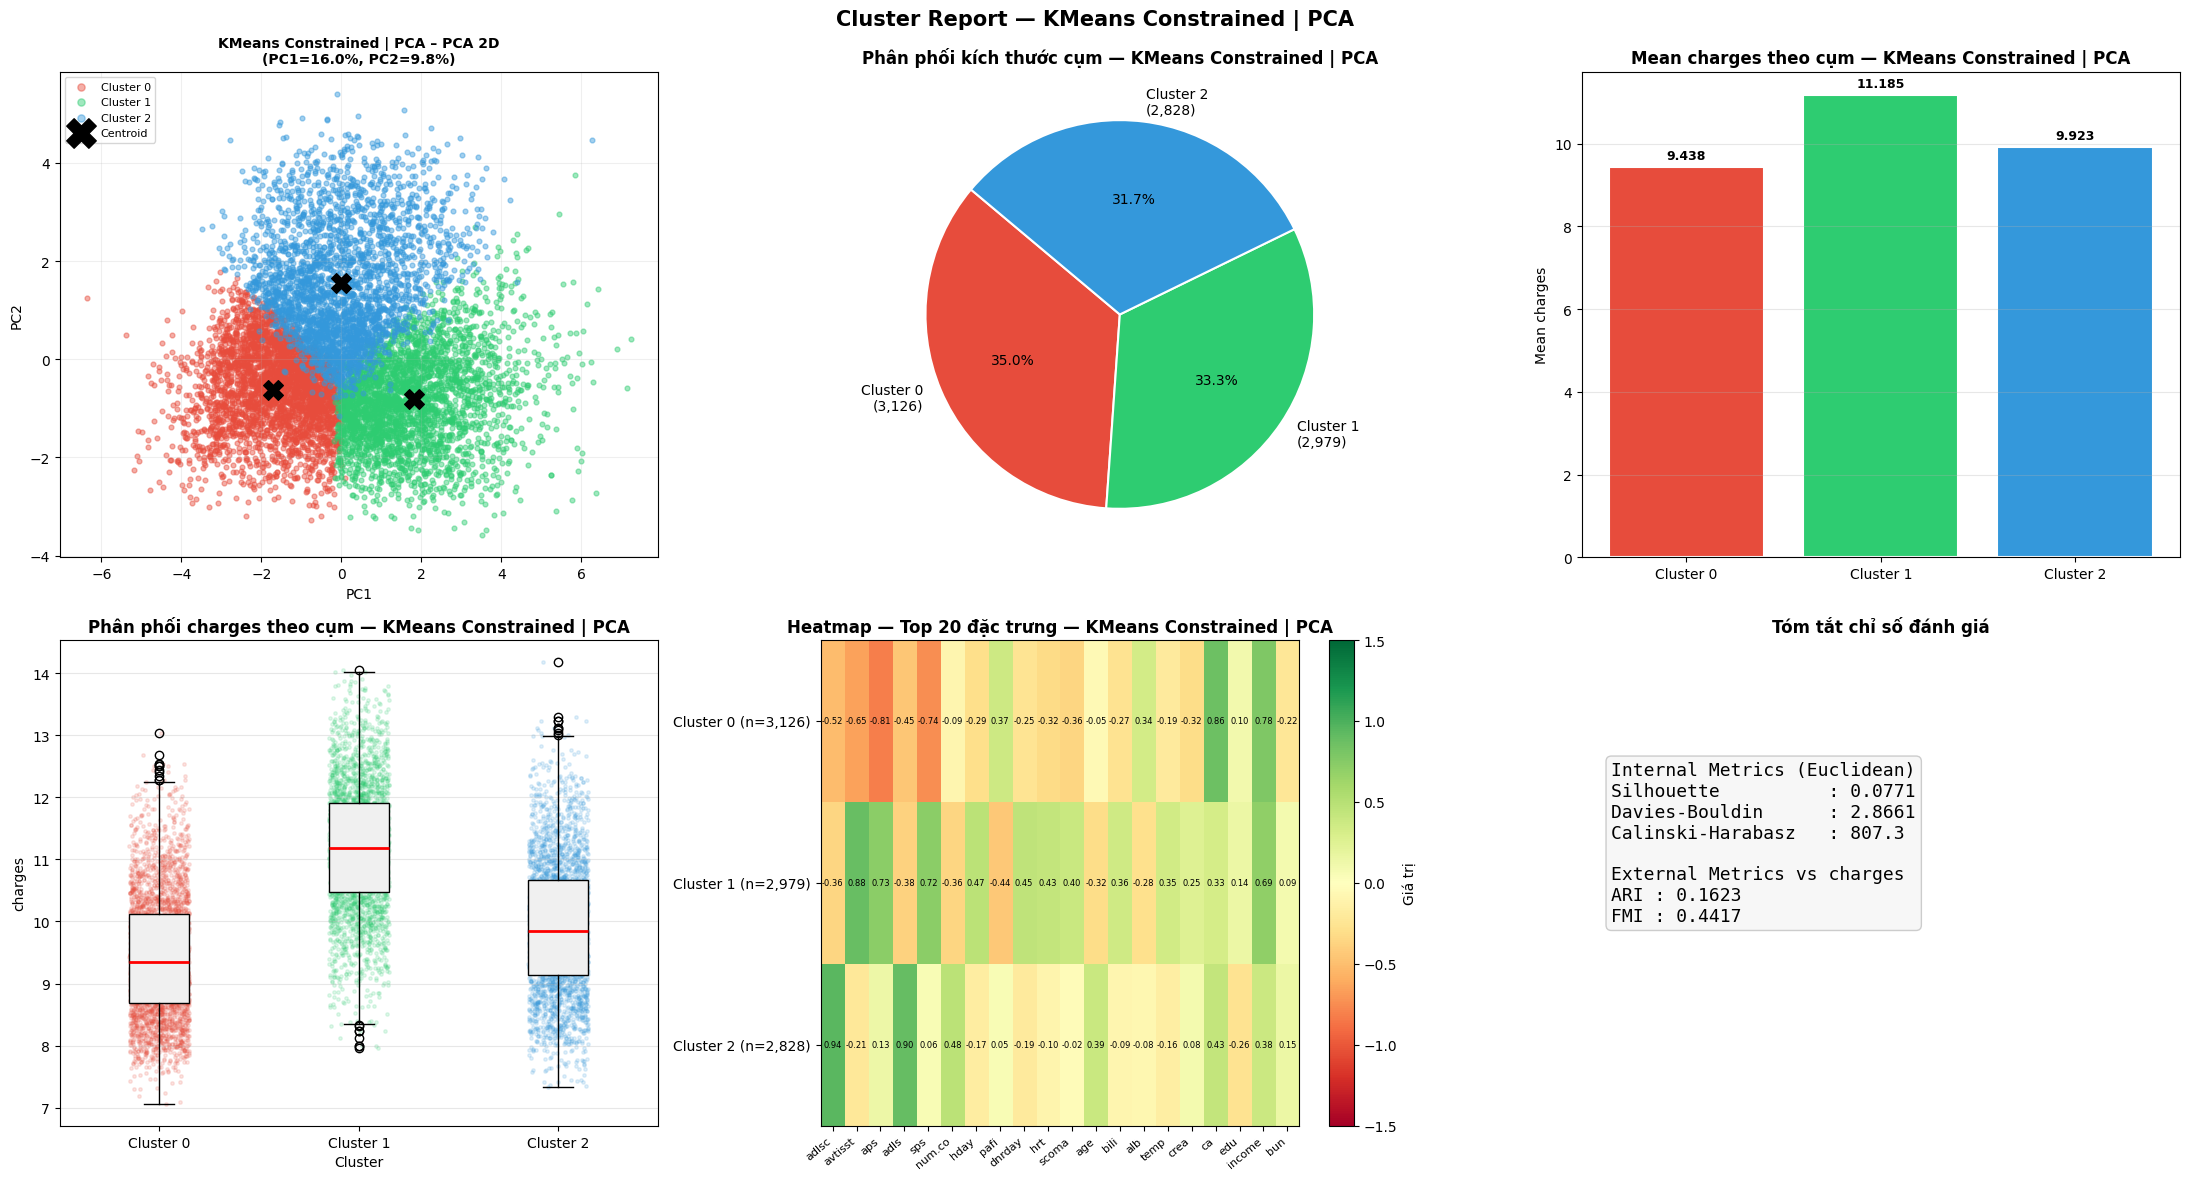

In [16]:
kcc_pca_labels, kcc_pca_metrics, kcc_pca_model = run_kmeans_constrained(
    X_cluster=X_pca_reduced,
    df=df,
    X_original=X,
    k=K_CLUSTERS,
    dim_name='PCA',
    tolerance=0.05,
    target_col=TARGET_COL
)

### 8.7 KMeans Constrained | UMAP


KMeans Constrained | UMAP | k=3 | tolerance=0.05
Số mẫu: 8933 | base/cụm: 2977 | [2828, 3126]
Phân phối cụm:
0    2828
1    3126
2    2979
Name: count, dtype: int64

  Internal Metrics (Euclidean) — KMeans Constrained | UMAP
  Silhouette Score     : +0.2931  (↑ tốt hơn, max=1)
  Davies-Bouldin Index : 1.0966   (↓ tốt hơn, min=0)
  Calinski-Harabasz    : 5767.6  (↑ tốt hơn)


  External Metrics — KMeans Constrained | UMAP vs 'charges'
  ARI : +0.1409  (>0 = tốt hơn ngẫu nhiên)
  FMI : 0.4274   (0→1, cao hơn tốt hơn)

  Mean 'charges' theo cụm:
    Cluster 2: 9.5455
    Cluster 0: 9.8231
    Cluster 1: 11.0906

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0            1261         951   616  2828
1             202         931  1993  3126
2            1515        1095   369  2979
All          2978        2977  2978  8933



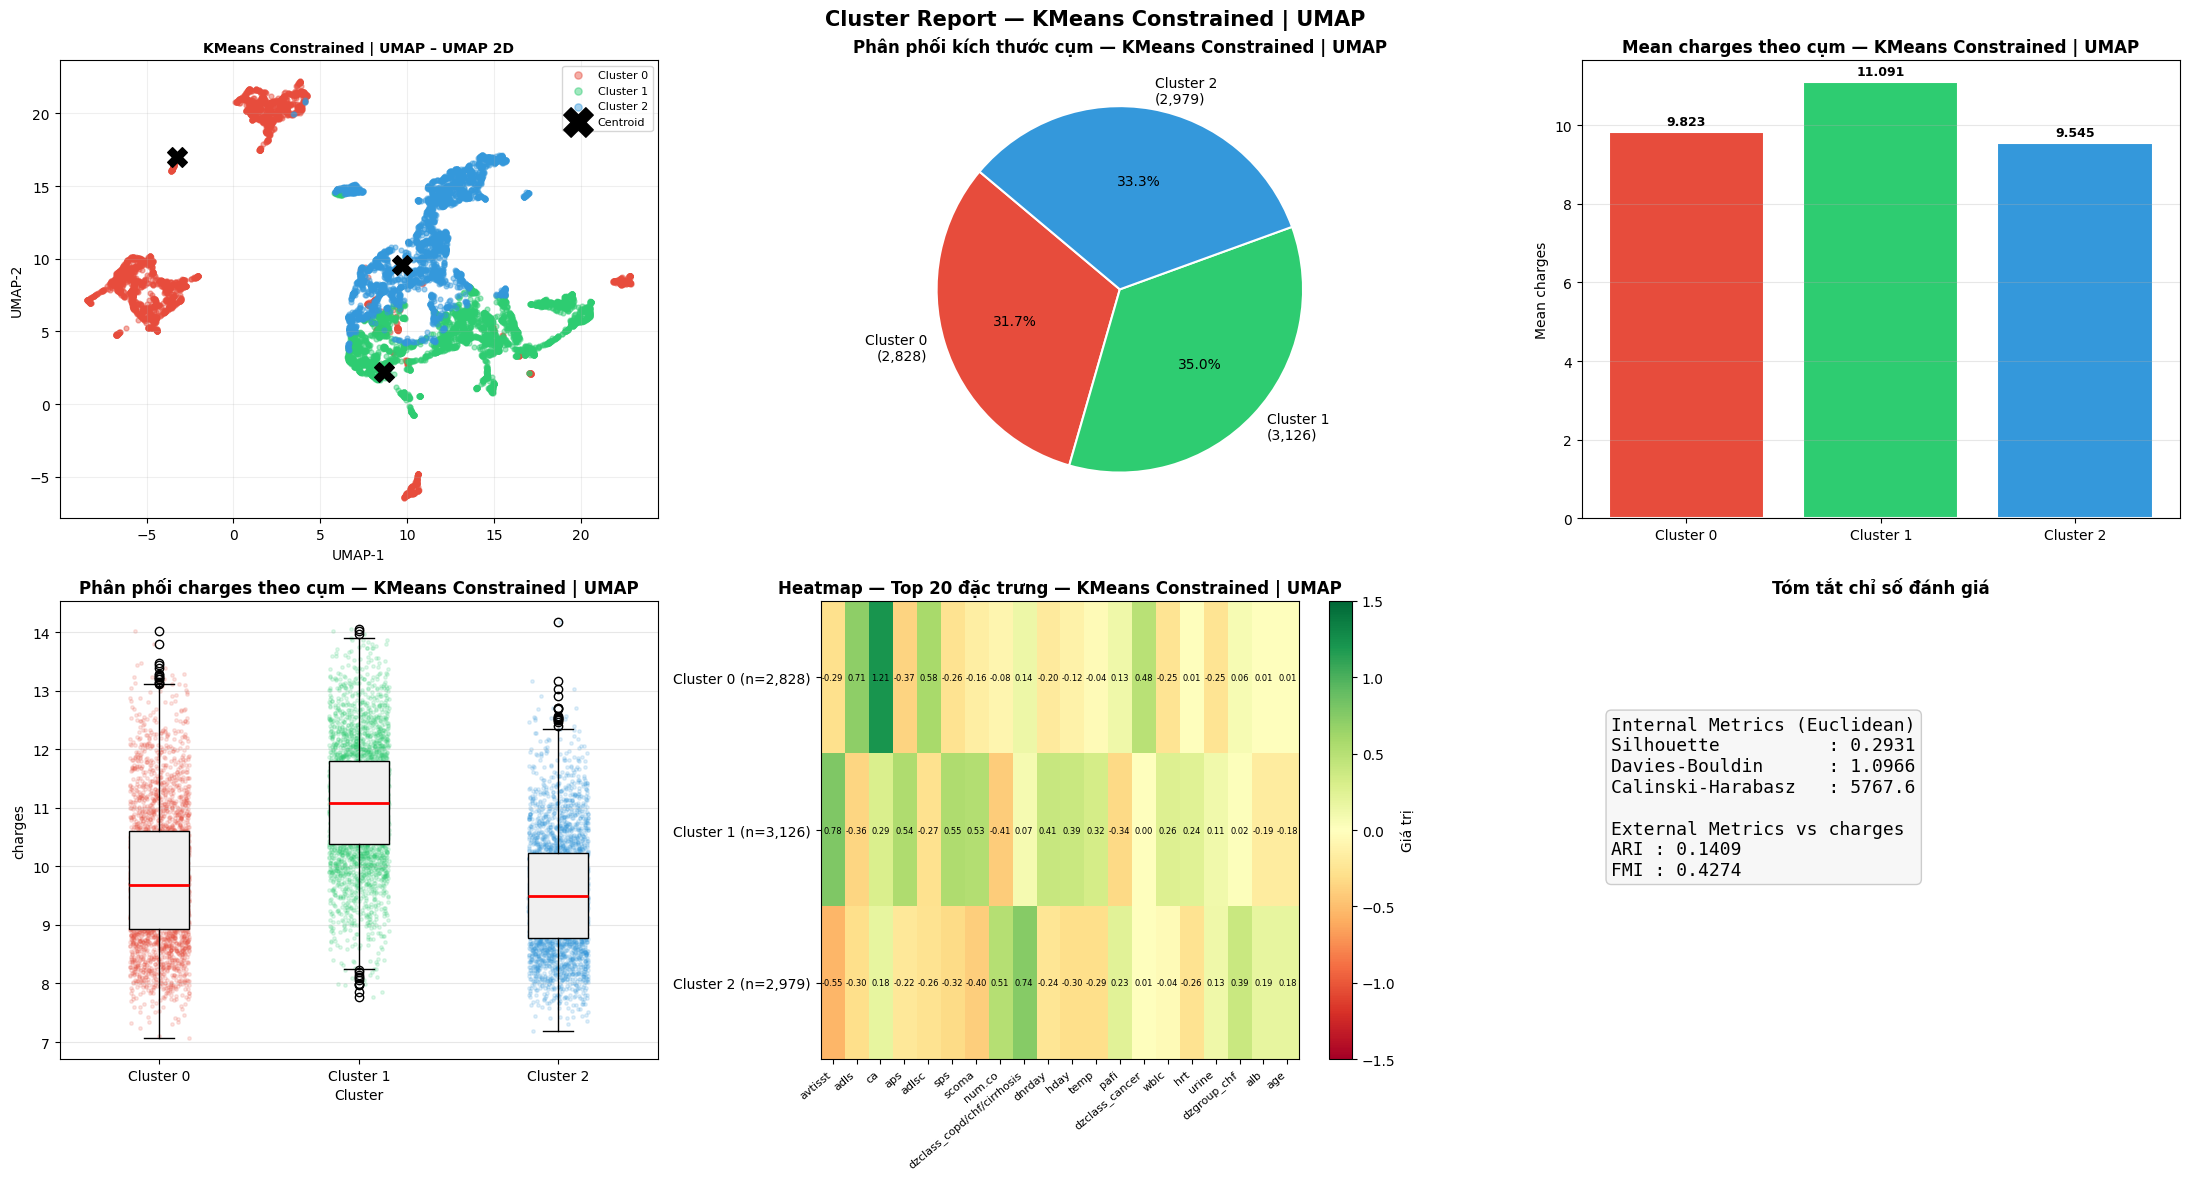

In [17]:
kcc_umap_labels, kcc_umap_metrics, kcc_umap_model = run_kmeans_constrained(
    X_cluster=X_umap_reduced,
    df=df,
    X_original=X,
    k=K_CLUSTERS,
    dim_name='UMAP',
    tolerance=0.05,
    target_col=TARGET_COL
)

## 9. So sánh tổng hợp tất cả phương pháp

In [18]:
all_metrics = [
    baseline_metrics,
    km_pca_metrics,
    km_umap_metrics,
    gower_pca_metrics,
    gower_umap_metrics,
    kcc_pca_metrics,
    kcc_umap_metrics,
]

# Chuẩn hóa key (ext_ari, ext_fmi từ full_cluster_report)
def extract_row(m):
    return {
        'Method'          : m.get('method', m.get('model', '?')),
        'Dim Reduction'   : m.get('dim_reduction', '-'),
        'k'               : m.get('k', K_CLUSTERS),
        'Silhouette ↑'    : round(m.get('silhouette', np.nan), 4),
        'Davies-Bouldin ↓': round(m.get('davies_bouldin', np.nan), 4),
        'Calinski-H ↑'    : round(m.get('calinski_harabasz', np.nan), 1),
        'ARI ↑'           : round(m.get('ext_ari', m.get('ari', np.nan)), 4),
        'FMI ↑'           : round(m.get('ext_fmi', m.get('fmi', np.nan)), 4),
    }

df_compare = pd.DataFrame([extract_row(m) for m in all_metrics])
display(df_compare)

,Method,Dim Reduction,k,Silhouette ↑,Davies-Bouldin ↓,Calinski-H ↑,ARI ↑,FMI ↑
0,KMeans Baseline,None,3,0.0873,2.9884,622.2,0.1895,0.4816
1,KMeans,PCA,3,0.1125,2.5224,862.2,0.1860,0.4786
2,KMeans,UMAP,3,0.3765,1.0674,10301.8,0.1564,0.4580
3,K-Medoids + Gower,PCA,3,0.1178,1.7267,568.6,0.0468,0.4270
4,K-Medoids + Gower,UMAP,3,0.3926,1.0874,9967.3,0.1427,0.4511
5,KMeans Constrained,PCA,3,0.0771,2.8661,807.3,0.1623,0.4417
6,KMeans Constrained,UMAP,3,0.2931,1.0966,5767.6,0.1409,0.4274


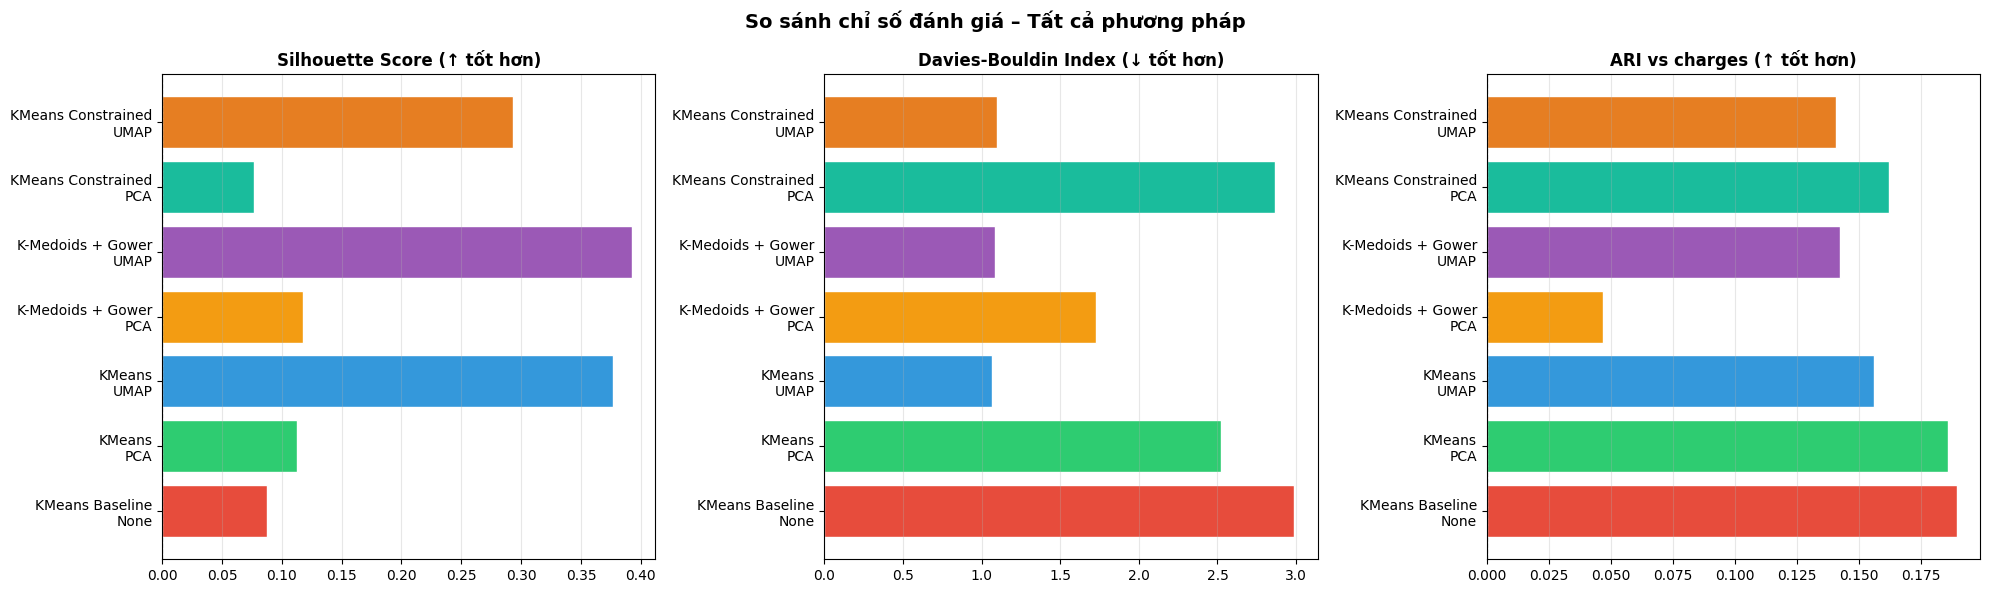

In [19]:
# ============================================================
# Bar chart so sánh Silhouette và Davies-Bouldin
# ============================================================
method_labels = [
    f"{r['Method']}\n{r['Dim Reduction']}"
    for _, r in df_compare.iterrows()
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('So sánh chỉ số đánh giá – Tất cả phương pháp',
             fontsize=14, fontweight='bold')

# Silhouette
axes[0].barh(method_labels, df_compare['Silhouette ↑'],
             color=COLORS[:len(df_compare)], edgecolor='white')
axes[0].set_title('Silhouette Score (↑ tốt hơn)', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(True, axis='x', alpha=0.3)

# Davies-Bouldin
axes[1].barh(method_labels, df_compare['Davies-Bouldin ↓'],
             color=COLORS[:len(df_compare)], edgecolor='white')
axes[1].set_title('Davies-Bouldin Index (↓ tốt hơn)', fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)

# ARI
axes[2].barh(method_labels, df_compare['ARI ↑'],
             color=COLORS[:len(df_compare)], edgecolor='white')
axes[2].set_title('ARI vs charges (↑ tốt hơn)', fontweight='bold')
axes[2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
k_values = range(2, 8)
results_k = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_umap_reduced)

    results_k.append({
        "k": k,
        "Silhouette": silhouette_score(X_umap_reduced, labels),
        "Davies-Bouldin": davies_bouldin_score(X_umap_reduced, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_umap_reduced, labels)
    })

pd.DataFrame(results_k)

,k,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.592297,0.483578,11497.465820
1,3,0.376518,1.067408,10301.813477
2,4,0.403770,0.884475,10160.189453
3,5,0.394979,0.991124,9838.786133
4,6,0.394248,0.988241,8888.210938
5,7,0.375537,1.097515,8377.229492


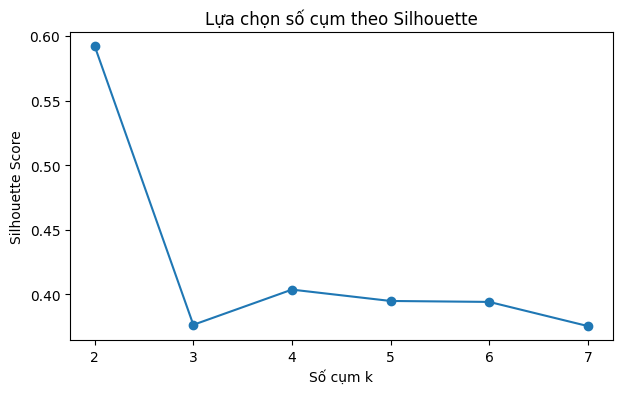

In [21]:
k_df = pd.DataFrame(results_k)

plt.figure(figsize=(7,4))
plt.plot(k_df["k"], k_df["Silhouette"], marker="o")
plt.xlabel("Số cụm k")
plt.ylabel("Silhouette Score")
plt.title("Lựa chọn số cụm theo Silhouette")
plt.show()